# GROMACS metatomic C API contracts

Open this notebook to check the numbers. Regenerate it with:

```bash
python3 src/gromacs/applied_forces/metatomic/docs/generate_c_api_notebook.py
```

What runs here:

- `libmetatomic`: `mta_unit_conversion_factor` (cutoffs and output units).
- vesin: the pair list, with `algorithm="cell_list"`. Its shift is the metatomic cell shift. The cubic shell count is the independent check.
- A harmonic ONIOM stand-in on `alanine_vacuo`, including a side-chain cut, the ALA residue as ML, and MM waters around that residue. Each run writes an extended XYZ trajectory.
- Plain Python: force and virial scatter, ONIOM removal rules, link frontiers.
- A source check that `setPairlist` reads both plain pair lists and that `tests/c_api_contract.cpp` records every stub.

What does not run here: a GROMACS build, `mta_execute_model`, or domain decomposition. Those stay as `GTEST_SKIP` in `tests/c_api_contract.cpp` until the C++ helpers exist. The NVE trace below is the harmonic stand-in, not `mdrun`.


## Setup

Load `libmetatensor` first (`RTLD_GLOBAL`), then `libmetatomic`. `METATOMIC_LIB` and `METATENSOR_LIB` override the search. Each later cell calls `check`, which records a pass and a microsecond timing.


In [1]:
import ctypes
import math
import os
import time
from pathlib import Path

RESULTS = []
EMBED = {"images": [], "files": []}

def check(name, fn):
    t0 = time.perf_counter()
    detail = fn()
    usec = (time.perf_counter() - t0) * 1e6
    RESULTS.append((name, usec, detail))
    print(f"PASS  {name:<52} {usec:10.1f} us  {detail}")

def _candidate_pairs():
    env_mta = os.environ.get("METATOMIC_LIB")
    env_mts = os.environ.get("METATENSOR_LIB")
    if env_mta or env_mts:
        if not (env_mta and env_mts):
            raise RuntimeError("set both METATOMIC_LIB and METATENSOR_LIB")
        yield Path(env_mts), Path(env_mta)
    home = Path.home()
    venv = home / "Documents/metawork/.venv/lib/python3.12/site-packages"
    yield (
        venv / "metatensor/lib/libmetatensor.so",
        venv / "metatomic/lib/libmetatomic.so",
    )
    release = (
        home
        / "Documents/metawork/metatomic/python/metatomic_core/build"
        / "cmake-build/metatomic-core/target/release"
    )
    mts_build = sorted((release / "build").glob("metatensor-sys-*/out/lib/libmetatensor.so"))
    if mts_build:
        yield mts_build[-1], release / "libmetatomic.so"

def load_metatomic():
    errors = []
    for mts, mta in _candidate_pairs():
        if not mts.is_file() or not mta.is_file():
            errors.append(f"missing {mts} or {mta}")
            continue
        try:
            ctypes.CDLL(str(mts), mode=ctypes.RTLD_GLOBAL)
            lib = ctypes.CDLL(str(mta))
        except OSError as exc:
            errors.append(f"{mta}: {exc}")
            continue
        lib.mta_unit_conversion_factor.argtypes = [
            ctypes.c_char_p,
            ctypes.c_char_p,
            ctypes.POINTER(ctypes.c_double),
        ]
        lib.mta_unit_conversion_factor.restype = ctypes.c_int
        lib.mta_last_error.argtypes = [
            ctypes.POINTER(ctypes.c_char_p),
            ctypes.POINTER(ctypes.c_char_p),
            ctypes.POINTER(ctypes.c_void_p),
        ]
        lib.mta_last_error.restype = ctypes.c_int
        return lib, mta
    raise RuntimeError("libmetatomic not loadable:\n" + "\n".join(errors))

LIB, LIB_PATH = load_metatomic()
print(f"libmetatomic: {LIB_PATH}")

def unit_factor(from_unit, to_unit):
    out = ctypes.c_double()
    status = LIB.mta_unit_conversion_factor(
        from_unit.encode(), to_unit.encode(), ctypes.byref(out)
    )
    if status != 0:
        msg = ctypes.c_char_p()
        origin = ctypes.c_char_p()
        data = ctypes.c_void_p()
        LIB.mta_last_error(ctypes.byref(msg), ctypes.byref(origin), ctypes.byref(data))
        text = msg.value.decode() if msg.value else f"status {status}"
        raise RuntimeError(text)
    return out.value

def unit_factor_status(from_unit, to_unit):
    out = ctypes.c_double()
    status = LIB.mta_unit_conversion_factor(
        from_unit.encode(), to_unit.encode(), ctypes.byref(out)
    )
    msg = ctypes.c_char_p()
    origin = ctypes.c_char_p()
    data = ctypes.c_void_p()
    LIB.mta_last_error(ctypes.byref(msg), ctypes.byref(origin), ctypes.byref(data))
    text = msg.value.decode() if msg.value else ""
    return status, text


libmetatomic: /home/boittier/Documents/metawork/.venv/lib/python3.12/site-packages/metatomic/lib/libmetatomic.so


## Part 1 and 2. Units

The runtime scales a clone. The engine buffer stays in nm. `"nm"` and `"nanometer"` are the same unit. An empty unit does not scale. A cutoff stored in angstrom is converted before GROMACS sees it: 5.0 Å is 0.5 nm. Requested energy is kJ/mol, so an eV model value is multiplied by the library factor before the force provider reads it. A dimension mismatch is an error.


In [2]:
def units():
    angstrom_to_nm = unit_factor("angstrom", "nm")
    cutoff_nm = 5.0 * angstrom_to_nm
    if not math.isclose(cutoff_nm, 0.5, abs_tol=1e-12):
        raise AssertionError(f"5.0 angstrom -> {cutoff_nm} nm")
    if not math.isclose(unit_factor("nm", "nanometer"), 1.0, abs_tol=1e-15):
        raise AssertionError("nm and nanometer differ")
    if not math.isclose(unit_factor("nm", "nm"), 1.0, abs_tol=1e-15):
        raise AssertionError("nm -> nm must be 1, so the runtime can share memory")
    if not math.isclose(unit_factor("", ""), 1.0, abs_tol=1e-15):
        raise AssertionError("empty units must not scale")
    ev_to_kj = unit_factor("eV", "kJ/mol")
    back = unit_factor("kJ/mol", "eV")
    if not math.isclose(ev_to_kj * back, 1.0, rel_tol=1e-12):
        raise AssertionError(f"eV round trip {ev_to_kj} * {back}")
    positions = [0.1, 0.2, 0.3]
    factor = unit_factor("nm", "angstrom")
    scaled = [p * factor for p in positions]
    if positions != [0.1, 0.2, 0.3]:
        raise AssertionError("scaling mutated the engine buffer")
    if scaled == positions:
        raise AssertionError("nm -> angstrom should change the clone")
    status, message = unit_factor_status("eV", "m")
    if status == 0 or "dimension mismatch" not in message:
        raise AssertionError(f"expected dimension mismatch, got {status} {message}")
    return f"5 A = {cutoff_nm:.6f} nm; 1 eV = {ev_to_kj:.6f} kJ/mol"

check("cutoff and energy units", units)


PASS  cutoff and energy units                                   100.0 us  5 A = 0.500000 nm; 1 eV = 96.485332 kJ/mol


## Part 3. Pair list

Sixty-four atoms on a 4×4×4 lattice, box 1.2 nm, cutoff 0.5 nm, periodic. There are no bonds, so an exclusions-only list is empty and the test fails if `setPairlist` ignores `pairlist_`. The pairs come from `vesin.NeighborList` with `algorithm="cell_list"`. This CPU build of vesin does not implement `brute_force`. Vesin's shift `S` is already the metatomic cell shift: `r_ij = x[j] + S·box - x[i]`, and the GROMACS shift is `-S`. An independent shell count (6 + 12 neighbors, body diagonal 0.520 nm is outside 0.5 nm) must agree with vesin. `full_list=True` returns each pair twice, with the reverse row negating `S` and the vector.


In [3]:
import numpy as np
from vesin import NeighborList

def lattice(n_side, box):
    axis = np.arange(n_side) / n_side
    frac = np.stack(np.meshgrid(axis, axis, axis, indexing="ij"), axis=-1)
    return frac.reshape(-1, 3) @ box

def vesin_pairs(positions, box, cutoff, full_list):
    """vesin cell list. ``shift`` is the metatomic cell shift."""
    neighbors = NeighborList(
        cutoff=cutoff,
        full_list=full_list,
        sorted=True,
        algorithm="cell_list",
    )
    first, second, shift, vectors = neighbors.compute(
        positions, box, True, quantities="ijSD"
    )
    return first, second, shift, vectors

def shell_count(n_side, box_length, cutoff):
    spacing = box_length / n_side
    steps = np.array(
        [(dx, dy, dz) for dx in (-1, 0, 1) for dy in (-1, 0, 1) for dz in (-1, 0, 1)]
    )
    steps = steps[np.any(steps != 0, axis=1)]
    neighbors = int(np.count_nonzero(spacing * np.linalg.norm(steps, axis=1) <= cutoff + 1e-12))
    return (n_side ** 3) * neighbors // 2

def pairs():
    n_side, box_length, cutoff = 4, 1.2, 0.5
    box = np.diag([box_length, box_length, box_length]).astype(float)
    positions = lattice(n_side, box)
    first, second, shift, vectors = vesin_pairs(
        positions, box, cutoff, full_list=False
    )
    expected = shell_count(n_side, box_length, cutoff)
    if len(first) != expected:
        raise AssertionError(f"vesin {len(first)} != shell {expected}")
    if len(first) == 0:
        raise AssertionError("lattice cutoff produced no pairs")
    body = (box_length / n_side) * math.sqrt(3.0)
    if not body > cutoff:
        raise AssertionError("body diagonal should sit outside the cutoff")
    rebuilt = positions[second] + shift @ box - positions[first]
    if not np.allclose(vectors, rebuilt, atol=1e-12):
        raise AssertionError("r_ij != x[j] + S·box - x[i]")
    distance = np.linalg.norm(vectors, axis=1)
    if np.any(distance > cutoff + 1e-12):
        raise AssertionError("pair outside cutoff")
    gmx_shift = -shift
    if not np.array_equal(shift, -gmx_shift):
        raise AssertionError("metatomic shift must negate the GROMACS shift")
    full_first, full_second, full_shift, full_vectors = vesin_pairs(
        positions, box, cutoff, full_list=True
    )
    if len(full_first) != 2 * len(first):
        raise AssertionError(f"full_list {len(full_first)} != 2 * {len(first)}")
    # The reverse row carries the negated shift and the negated vector.
    half = {(int(i), int(j)): (s, v) for i, j, s, v in zip(first, second, shift, vectors)}
    matched = 0
    for i, j, s, v in zip(full_first, full_second, full_shift, full_vectors):
        forward = half.get((int(i), int(j)))
        if forward is not None:
            if not (np.array_equal(s, forward[0]) and np.allclose(v, forward[1])):
                raise AssertionError("full_list changed a half-list row")
            continue
        backward = half.get((int(j), int(i)))
        if backward is None:
            raise AssertionError(f"full_list pair {(int(i), int(j))} is not the reverse of a half-list pair")
        if not np.array_equal(s, -backward[0]) or not np.allclose(v, -backward[1]):
            raise AssertionError("reverse pair must negate the shift and the vector")
        matched += 1
    if matched != len(first):
        raise AssertionError(f"found {matched} reverse pairs, expected {len(first)}")
    return f"{len(first)} pairs (full_list {len(full_first)}); body diagonal {body:.3f} nm"

check("64-atom pair count matches both oracles", pairs)

def triclinic():
    box = np.array(
        [[1.2, 0.0, 0.0], [0.2, 1.1, 0.0], [0.1, 0.15, 1.0]],
        dtype=float,
    )
    positions = lattice(4, box)
    first, second, shift, vectors = vesin_pairs(positions, box, 0.5, full_list=False)
    if len(first) == 0:
        raise AssertionError("triclinic lattice produced no pairs")
    rebuilt = positions[second] + shift @ box - positions[first]
    if not np.allclose(vectors, rebuilt, atol=1e-12):
        raise AssertionError("triclinic r_ij does not match vesin's shift")
    wrapped = int(np.count_nonzero(np.any(shift != 0, axis=1)))
    if wrapped == 0:
        raise AssertionError("triclinic cell produced no wrapped pair")
    return f"{len(first)} pairs, {wrapped} with a non-zero cell shift"

check("triclinic cell shifts", triclinic)


PASS  64-atom pair count matches both oracles                 25463.0 us  576 pairs (full_list 1152); body diagonal 0.520 nm
PASS  triclinic cell shifts                                     484.2 us  768 pairs, 327 with a non-zero cell shift


## Part 3 and 4. Selected atoms, forces, virial

`selected_atoms` is `(system, atom)` for home atoms only. Position-gradient values are `-F`, and the engine does `force -= value`. Two rows that store `(-1, 0, 0)` and `(0, -2, 0)` for atom 1 become force `(1, 2, 0)`. A row whose atom is past `numHomeMta_` goes to the halo exchange and is not written into the local buffer. The strain gradient is `V * sigma`; the GROMACS virial takes `+0.5`, because `execute_model` does not differentiate `-E`. Non-conservative forces are already forces. They are not negated and they are not halo-exchanged. Non-conservative stress uses `0.5 * stress * volume`.


In [4]:
def scatter():
    num_home = 2
    selected = [(0, atom) for atom in range(num_home)]
    if selected != [(0, 0), (0, 1)]:
        raise AssertionError(selected)

    # Stored gradient values are -F. Engine does force -= value.
    # -F = (-1, 0, 0) and (0, -2, 0) => F = (1, 2, 0).
    gradient_rows = [
        (1, (-1.0, 0.0, 0.0)),
        (3, (-4.0, 0.0, 0.0)),
        (1, (0.0, -2.0, 0.0)),
    ]
    local = {}
    halo = []
    for atom, value in gradient_rows:
        if atom >= num_home:
            halo.append(atom)
            continue
        prev = local.get(atom, (0.0, 0.0, 0.0))
        local[atom] = tuple(a - b for a, b in zip(prev, value))
    if local[1] != (1.0, 2.0, 0.0):
        raise AssertionError(local[1])
    if halo != [3] or 3 in local:
        raise AssertionError("halo atom was written into the local buffer")

    strain_xx = 2.0
    virial_xx = 0.5 * strain_xx
    if virial_xx != 1.0:
        raise AssertionError("strain virial factor must be +0.5")
    if (-0.5 * strain_xx) == virial_xx:
        raise AssertionError("the old backward-on-minus-E sign came back")

    nc_rows = [(1, (0.5, 0.0, -0.25))]
    nc_local = {}
    for atom, value in nc_rows:
        if atom >= num_home:
            raise AssertionError("non-conservative samples are home-only")
        nc_local[atom] = value
    if nc_local[1] != (0.5, 0.0, -0.25):
        raise AssertionError("non-conservative force was negated")
    try:
        for atom, _value in [(3, (0.5, 0.0, -0.25))]:
            if atom >= num_home:
                raise RuntimeError("halo")
    except RuntimeError:
        pass
    else:
        raise AssertionError("a halo non-conservative sample must be rejected")
    stress_xx, volume = 4.0, 2.0
    nc_virial = 0.5 * stress_xx * volume
    if nc_virial != 4.0:
        raise AssertionError(nc_virial)
    return "F[1]=(1, 2, 0); strain virial xx=1; nc virial xx=4"

check("home atoms, gradient scatter, virial sign", scatter)


PASS  home atoms, gradient scatter, virial sign                  10.3 us  F[1]=(1, 2, 0); strain virial xx=1; nc virial xx=4


## Part 6. ONIOM removal rules and link frontiers

An angle is removed only when all 3 atoms are ML. A dihedral is removed only when all 4 are ML. A bond is removed only when both atoms are ML. The alanine-vacuo index set is `{8, 9, 10, 11, 12, 13}`. Link atoms: 4 copies in one molblock, one boundary bond per copy. Walking every molecule yields 4 frontiers. Walking only `globalAtomStart` yields 1, which is the lipid bug.


In [5]:
ML = {8, 9, 10, 11, 12, 13}

def removed(atoms, ml, kind):
    n_ml = sum(atom in ml for atom in atoms)
    if kind == "bond":
        return n_ml == 2
    if kind == "angle":
        return n_ml == 3
    if kind == "dihedral":
        return n_ml == 4
    raise AssertionError(kind)

def oniom_rules():
    cases = [
        ("angle", (8, 9, 10), True),
        ("angle", (8, 9, 7), False),
        ("dihedral", (8, 9, 10, 11), True),
        ("dihedral", (8, 9, 10, 7), False),
        ("bond", (8, 9), True),
        ("bond", (7, 8), False),
    ]
    for kind, atoms, expect_removed in cases:
        got = removed(atoms, ML, kind)
        if got != expect_removed:
            raise AssertionError(f"{kind} {atoms}: removed={got}, expected {expect_removed}")
    return "boundary angle and dihedral kept; all-ML terms removed"

def link_frontiers(n_copies, only_block_start):
    copies = range(1 if only_block_start else n_copies)
    return [copy for copy in copies]

def links():
    fixed = link_frontiers(4, only_block_start=False)
    buggy = link_frontiers(4, only_block_start=True)
    if fixed != [0, 1, 2, 3] or buggy != [0]:
        raise AssertionError((fixed, buggy))
    return f"{len(fixed)} frontiers in the block; block-start walk returns {len(buggy)}"

check("ONIOM keeps boundary angles and dihedrals", oniom_rules)
check("link frontier in every molecule of a block", links)


PASS  ONIOM keeps boundary angles and dihedrals                   6.4 us  boundary angle and dihedral kept; all-ML terms removed
PASS  link frontier in every molecule of a block                  2.9 us  4 frontiers in the block; block-start walk returns 1


## Source check

The GoogleTest file records the contracts and skips. This cell checks that those names are present, that the test target lists the file, and that `setPairlist` appends both plain pair lists.


In [6]:
MODULE = Path('/home/boittier/Documents/metawork/gromacs/src/gromacs/applied_forces/metatomic')

EXPECTED_TESTS = [
    "TEST(CApiEveryCall, ChecksTypesAndScalesUnitsWithoutConsistency)",
    "TEST(CApiCheckConsistency, RejectsDtypeDeviceAndExtraSamples)",
    "TEST(CApiSystem, OwnsTensorsAndRejectsNonZeroVacuumRow)",
    "TEST(CApiPairs, ChecksLayoutAndNotDistances)",
    "TEST(CApiEnergyBlock, SumsByLabelAndKeepsGradientSign)",
    "TEST(CApiGromacsOnly, HomeRangeAndHaloExchange)",
    "TEST(CApiLoad, LoadsPluginAndKeepsModelAlive)",
    "TEST(CApiLoad, ConvertsModelCutoffToNm)",
    "TEST(CApiLoad, BuildsQuantityListInGromacsUnits)",
    "TEST(CApiStep, WrapsGromacsBuffersWithoutCopyingWhenDtypesMatch)",
    "TEST(CApiStep, FiltersCutoffOnlyWhenStrict)",
    "TEST(CApiStep, PassesHomeAtomsAndIndexesOutputsByRequestOrder)",
    "TEST(CApiForces, AccumulatesPositionsGradientByAtomLabel)",
    "TEST(CApiForces, HalvesStrainGradientForGromacsVirial)",
    "TEST(CApiForces, ScattersNonConservativeForcesWithoutNegating)",
    "TEST(CApiBuild, DoesNotLinkTorch)",
    "TEST(OniomTopology, KeepsBoundaryAnglesAndDihedrals)",
    "TEST(OniomLinks, FindsFrontierInEveryMoleculeOfABlock)",
    "TEST(NlCapacity, PairCountMatchesBruteForce)",
    "TEST(OniomMd, ConservedEnergyDriftBound)",
]

def sources():
    tests = (MODULE / "tests/c_api_contract.cpp").read_text()
    cmake = (MODULE / "tests/CMakeLists.txt").read_text()
    provider = (MODULE / "metatomic_forceprovider.cpp").read_text()
    missing = [name for name in EXPECTED_TESTS if name not in tests]
    if missing:
        raise AssertionError("missing tests: " + ", ".join(missing))
    if "c_api_contract.cpp" not in cmake:
        raise AssertionError("test target does not list c_api_contract.cpp")
    if "appendPairlistEntries(signal.pairlist_)" not in provider:
        raise AssertionError("setPairlist does not read pairlist_")
    if "appendPairlistEntries(signal.excludedPairlist_)" not in provider:
        raise AssertionError("setPairlist does not read excludedPairlist_")
    return f"{len(EXPECTED_TESTS)} stubs present; both pair lists appended"

check("sources match the recorded contracts", sources)


PASS  sources match the recorded contracts                      220.4 us  20 stubs present; both pair lists appended


## ONIOM setups and short NVE runs

`alanine_vacuo` is the ACE-ALA-NME peptide from the GROMACS test database. Three cuts use the same harmonic stand-in. Bonds shorter than 0.17 nm come from vesin. The MM spring constant is `2e4 kJ/mol/nm^2`. Bonds inside the ML region also get an ML spring of `4e4`. The ONIOM force is `F_MM(full) + F_ML(model) - F_MM(model)`.

- **Side chain.** ML atoms `{8, 9, 10, 11, 12, 13}` (CA, HA, CB, HB1, HB2, HB3). The rest of the peptide is MM.
- **ALA residue.** ML is residue ALA (N through O, indices 6–15). ACE and NME are MM.
- **ALA plus waters.** The same ALA region is ML. Eight waters sit around the peptide and are MM, together with the caps. A soft wall between each water oxygen and the solute, inside 0.40 nm, is part of `E_MM(full)` only.

Each setup runs 40 velocity-Verlet steps at 50 K, `dt = 0.0002 ps`. The extended XYZ files are in Ångström, with `subsystem` (1 = ML) and forces in kJ/mol/nm. Open them in OVITO, ASE, or VMD. This is not a GROMACS `mdrun`.


side chain       ML  6  MM 16  waters  0  bonds  5  drift  5.095e-04  |F| ML  164.77  MM-solute   48.57  water    0.00
ALA residue      ML 10  MM 12  waters  0  bonds  9  drift  5.956e-04  |F| ML  152.51  MM-solute   38.91  water    0.00
ALA + waters     ML 10  MM 36  waters  8  bonds  9  drift  1.367e-03  |F| ML  152.51  MM-solute   38.91  water   74.00
PASS  three ONIOM cuts, 40-step NVE                          139910.7 us  3 trajectories, drift below 0.1%
PASS  lattice neighbor count                                    852.8 us  coordination 18 on every site


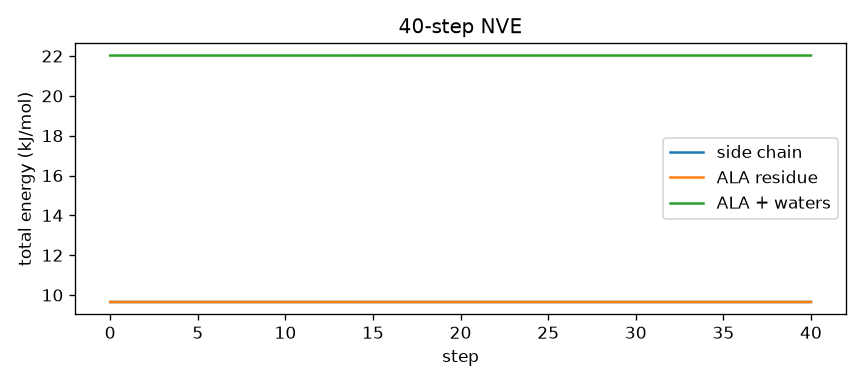

trajectories/oniom-sidechain.xyz
trajectories/oniom-ala-residue.xyz
trajectories/oniom-ala-waters.xyz
trajectories/lattice-4x4x4.xyz

In [7]:
import base64
import io

import numpy as np

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-c-api")
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

SYMBOL = {
    "CH3": "C", "HH31": "H", "HH32": "H", "HH33": "H",
    "C": "C", "O": "O", "N": "N", "H": "H",
    "CA": "C", "HA": "H", "CB": "C",
    "HB1": "H", "HB2": "H", "HB3": "H",
    "OW": "O", "HW1": "H", "HW2": "H",
}
MASS = {"H": 1.008, "C": 12.011, "N": 14.007, "O": 15.999}
SIDE_CHAIN = {8, 9, 10, 11, 12, 13}
ALA_RESIDUE = set(range(6, 16))
K_MM = 2.0e4
K_ML = 4.0e4
K_WALL = 5.0e2
R_WALL = 0.40

def read_alanine():
    gro = (MODULE.parents[2] / "testutils/simulationdatabase/alanine_vacuo.gro").read_text().splitlines()
    n_atoms = int(gro[1])
    names, positions = [], []
    for line in gro[2:2 + n_atoms]:
        names.append(line[10:15].strip())
        positions.append([float(line[20:28]), float(line[28:36]), float(line[36:44])])
    return names, np.array(positions)

def add_waters(names, positions, n_waters=8):
    com = positions.mean(axis=0)
    oh = 0.09572
    half = np.deg2rad(104.52 / 2.0)
    extra_names, extra_pos = [], []
    for water in range(n_waters):
        theta = 2.0 * np.pi * water / n_waters
        outward = np.array([np.cos(theta), np.sin(theta), 0.35 * (1 if water % 2 == 0 else -1)])
        outward = outward / np.linalg.norm(outward)
        oxygen = com + outward * 0.90
        for _push in range(12):
            if np.linalg.norm(positions - oxygen, axis=1).min() >= 0.34:
                break
            oxygen = oxygen + outward * 0.04
        reference = np.array([0.0, 0.0, 1.0])
        if abs(np.dot(outward, reference)) > 0.9:
            reference = np.array([0.0, 1.0, 0.0])
        side = np.cross(outward, reference)
        side = side / np.linalg.norm(side)
        h1 = oxygen + oh * (np.cos(half) * outward + np.sin(half) * side)
        h2 = oxygen + oh * (np.cos(half) * outward - np.sin(half) * side)
        extra_names.extend(["OW", "HW1", "HW2"])
        extra_pos.extend([oxygen, h1, h2])
    return names + extra_names, np.vstack([positions, np.array(extra_pos)])

def pair_forces(positions, first, second, r0, k):
    if len(first) == 0:
        return np.zeros_like(positions), 0.0
    rij = positions[second] - positions[first]
    distance = np.linalg.norm(rij, axis=1)
    unit = rij / distance[:, None]
    stretch = distance - r0
    pair_force = (k * stretch)[:, None] * unit
    forces = np.zeros_like(positions)
    np.add.at(forces, first, pair_force)
    np.add.at(forces, second, -pair_force)
    return forces, float(0.5 * k * np.sum(stretch * stretch))

def wall_forces(positions, n_solute):
    oxygen = np.arange(n_solute, len(positions), 3)
    if len(oxygen) == 0:
        return np.zeros_like(positions), 0.0
    solute = np.arange(n_solute)
    delta = positions[oxygen][:, None, :] - positions[solute][None, :, :]
    distance = np.linalg.norm(delta, axis=2)
    active = distance < R_WALL
    stretch = np.where(active, distance - R_WALL, 0.0)
    safe = np.where(distance > 1.0e-8, distance, 1.0)
    unit = delta / safe[:, :, None]
    pair_force = (K_WALL * stretch)[:, :, None] * unit
    forces = np.zeros_like(positions)
    # stretch is negative inside the wall, and unit points from solute to oxygen.
    # The oxygen is pushed outward.
    np.add.at(forces, oxygen, -pair_force.sum(axis=1))
    np.add.at(forces, solute, pair_force.sum(axis=0))
    return forces, float(0.5 * K_WALL * np.sum(stretch * stretch))

def oniom_forces(positions, bonds, n_solute):
    first, second, r0, model = bonds
    f_mm, e_mm = pair_forces(positions, first, second, r0, K_MM)
    f_model, e_model = pair_forces(positions, first[model], second[model], r0[model], K_MM)
    f_ml, e_ml = pair_forces(positions, first[model], second[model], r0[model], K_ML)
    f_wall, e_wall = wall_forces(positions, n_solute)
    force = f_mm + f_ml - f_model + f_wall
    energy = e_mm + e_ml - e_model + e_wall
    return force, energy, f_mm, f_ml, f_model, f_wall

def bonds_for(positions, ml):
    box = np.diag([8.0, 8.0, 8.0])
    first, second, shift, vectors = vesin_pairs(positions, box, 0.17, full_list=False)
    keep = np.all(shift == 0, axis=1)
    first, second, vectors = first[keep], second[keep], vectors[keep]
    r0 = np.linalg.norm(vectors, axis=1)
    model = np.array([(int(i) in ml) and (int(j) in ml) for i, j in zip(first, second)])
    return first, second, r0, model

def write_extxyz(path, symbols, frames):
    lines = []
    for step, coords, force, energy, subsystem in frames:
        lines.append(str(len(symbols)))
        lines.append(
            'Properties=species:S:1:pos:R:3:subsystem:I:1:forces:R:3 '
            f'energy={energy:.8f} step={step} '
            'pos_unit=Angstrom force_unit=kJ/mol/nm pbc="F F F"'
        )
        for symbol, xyz, bit, fvec in zip(symbols, coords * 10.0, subsystem, force):
            lines.append(
                f"{symbol} {xyz[0]:.6f} {xyz[1]:.6f} {xyz[2]:.6f} {int(bit)} "
                f"{fvec[0]:.6f} {fvec[1]:.6f} {fvec[2]:.6f}"
            )
    path.write_text("\n".join(lines) + "\n")

def run_setup(label, filename, ml, with_waters):
    names, positions = read_alanine()
    n_solute = len(names)
    if with_waters:
        names, positions = add_waters(names, positions)
    ml = set(ml)
    if any(atom >= n_solute for atom in ml):
        raise AssertionError("ML indices must stay on the solute")
    symbols = [SYMBOL[name] for name in names]
    masses = np.array([MASS[symbol] for symbol in symbols])
    subsystem = np.array([1 if atom in ml else 0 for atom in range(len(names))])
    n_water = len(names) - n_solute
    bonds = bonds_for(positions, ml)
    if int(bonds[3].sum()) == 0:
        raise AssertionError(f"{label} has no bond inside the ML region")
    # Waters must stay out of the ML region, and a water oxygen must not start inside the wall.
    if n_water:
        oxygen = np.arange(n_solute, len(names), 3)
        if np.any(subsystem[oxygen] != 0):
            raise AssertionError("a water was marked ML")
        clearance = np.linalg.norm(positions[oxygen][:, None, :] - positions[:n_solute][None, :, :], axis=2).min()
        if clearance < 0.30:
            raise AssertionError(f"water overlaps the solute, min distance {clearance:.3f} nm")

    kB = 0.008314462618
    rng = np.random.default_rng(1)
    velocity = rng.normal(size=positions.shape) * np.sqrt(kB * 50.0 / masses)[:, None]
    velocity -= np.average(velocity, axis=0, weights=masses)
    coords = positions.copy()
    force, energy, f_mm, f_ml, f_model, f_wall = oniom_forces(coords, bonds, n_solute)
    acceleration = force / masses[:, None]
    dt = 2.0e-4
    trace = []
    saved = []
    for step in range(41):
        kinetic = float(0.5 * np.sum(masses * np.sum(velocity * velocity, axis=1)))
        trace.append((energy + kinetic, kinetic, energy, float(np.linalg.norm(coords - positions, axis=1).max())))
        if step % 5 == 0:
            saved.append((step, coords.copy(), force.copy(), energy + kinetic, subsystem.copy()))
        coords = coords + velocity * dt + 0.5 * acceleration * dt * dt
        force, energy, f_mm, f_ml, f_model, f_wall = oniom_forces(coords, bonds, n_solute)
        acceleration_new = force / masses[:, None]
        velocity = velocity + 0.5 * (acceleration + acceleration_new) * dt
        acceleration = acceleration_new
    if not np.isfinite(coords).all():
        raise AssertionError(f"{label} NVE left the real line")
    drift = trace[-1][0] - trace[0][0]
    if abs(drift) / abs(trace[0][0]) > 1.0e-3:
        raise AssertionError(f"{label} energy drift {drift} kJ/mol")
    if trace[-1][3] > 0.08:
        raise AssertionError(f"{label} moved {trace[-1][3]} nm")
    mm = subsystem == 0
    if not np.allclose(f_ml[mm], 0.0) or not np.allclose(f_model[mm], 0.0):
        raise AssertionError(f"{label}: an MM atom received a model force")
    if not np.allclose(force, f_mm + f_ml - f_model + f_wall):
        raise AssertionError(f"{label}: ONIOM force identity failed")
    if n_water and not np.allclose(force[n_solute:], f_mm[n_solute:] + f_wall[n_solute:]):
        raise AssertionError(f"{label}: water force is not the MM full-system force")

    traj = MODULE / "docs" / "trajectories"
    traj.mkdir(exist_ok=True)
    path = traj / filename
    write_extxyz(path, symbols, saved)
    EMBED["files"].append({
        "href": f"trajectories/{filename}",
        "title": label,
    })
    ml_force = float(np.linalg.norm(force[subsystem == 1], axis=1).mean())
    mm_solute = np.arange(n_solute)[subsystem[:n_solute] == 0]
    mm_force = float(np.linalg.norm(force[mm_solute], axis=1).mean()) if len(mm_solute) else 0.0
    water_force = float(np.linalg.norm(force[n_solute:], axis=1).mean()) if n_water else 0.0
    print(
        f"{label:<16} ML {int(subsystem.sum()):2d}  MM {int((subsystem == 0).sum()):2d}  "
        f"waters {n_water // 3:2d}  bonds {int(bonds[3].sum()):2d}  "
        f"drift {drift: .3e}  |F| ML {ml_force:7.2f}  MM-solute {mm_force:7.2f}  water {water_force:7.2f}"
    )
    return [row[0] for row in trace], label

def oniom_setups():
    curves = [
        run_setup("side chain", "oniom-sidechain.xyz", SIDE_CHAIN, False),
        run_setup("ALA residue", "oniom-ala-residue.xyz", ALA_RESIDUE, False),
        run_setup("ALA + waters", "oniom-ala-waters.xyz", ALA_RESIDUE, True),
    ]
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    for totals, label in curves:
        ax.plot(totals, label=label)
    ax.set_xlabel("step")
    ax.set_ylabel("total energy (kJ/mol)")
    ax.set_title("40-step NVE")
    ax.legend()
    fig.tight_layout()
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=120)
    plt.close(fig)
    EMBED["images"].append({
        "title": "NVE total energy for the three ONIOM cuts",
        "png": base64.b64encode(buffer.getvalue()).decode(),
    })
    return "3 trajectories, drift below 0.1%"

def lattice_count():
    box = np.diag([1.2, 1.2, 1.2])
    positions = lattice(4, box)
    first, second, _shift, _vectors = vesin_pairs(positions, box, 0.5, full_list=False)
    coordination = np.zeros(len(positions), dtype=int)
    np.add.at(coordination, first, 1)
    np.add.at(coordination, second, 1)
    if not np.all(coordination == 18):
        raise AssertionError(f"coordination {set(coordination.tolist())}")
    traj = MODULE / "docs" / "trajectories"
    traj.mkdir(exist_ok=True)
    path = traj / "lattice-4x4x4.xyz"
    symbols = ["C"] * len(positions)
    frames = [(0, positions, np.zeros_like(positions), 0.0, coordination)]
    # subsystem column stores the neighbor count for this file
    write_extxyz(path, symbols, frames)
    text = path.read_text().splitlines()
    text[1] = text[1].replace("subsystem:I:1", "neighbors:I:1")
    path.write_text("\n".join(text) + "\n")
    EMBED["files"].append({"href": "trajectories/lattice-4x4x4.xyz", "title": "4x4x4 lattice, neighbor count in the neighbors column"})
    return "coordination 18 on every site"

check("three ONIOM cuts, 40-step NVE", oniom_setups)
check("lattice neighbor count", lattice_count)


## Timings

Each `check` above is one row. The pair-list rows are vesin's cell-list neighbor search. Unit conversion is one library call per factor, so its time includes the first `mta_unit_conversion_factor` from this process.


In [8]:
print(f"{'check':<52} {'us':>10}")
total = 0.0
for name, usec, detail in RESULTS:
    total += usec
    print(f"{name:<52} {usec:10.1f}  {detail}")
print(f"{'total':<52} {total:10.1f}")


check                                                        us
cutoff and energy units                                   100.0  5 A = 0.500000 nm; 1 eV = 96.485332 kJ/mol
64-atom pair count matches both oracles                 25463.0  576 pairs (full_list 1152); body diagonal 0.520 nm
triclinic cell shifts                                     484.2  768 pairs, 327 with a non-zero cell shift
home atoms, gradient scatter, virial sign                  10.3  F[1]=(1, 2, 0); strain virial xx=1; nc virial xx=4
ONIOM keeps boundary angles and dihedrals                   6.4  boundary angle and dihedral kept; all-ML terms removed
link frontier in every molecule of a block                  2.9  4 frontiers in the block; block-start walk returns 1
sources match the recorded contracts                      220.4  20 stubs present; both pair lists appended
three ONIOM cuts, 40-step NVE                          139910.7  3 trajectories, drift below 0.1%
lattice neighbor count                       